# Credit Card Fraud Detection

## 1. Setup

The project uses standard Python ML libraries. Optional packages are handled gracefully:

- `imblearn` enables SMOTE pipelines.
- `xgboost` enables the XGBoost model; otherwise the notebook uses `HistGradientBoostingClassifier`.
- `shap` enables SHAP interpretability plots; otherwise the notebook reports a clear message and still provides permutation/model importance alternatives.

Suggested environment setup:

```bash
pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn xgboost shap
```

In [1]:
#%pip install seaborn imbalanced-learn xgboost shap

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
DATA_PATH = Path("creditcard.csv")

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBLEARN = True
except Exception as exc:
    SMOTE = None
    ImbPipeline = Pipeline
    HAS_IMBLEARN = False
    print(f"imblearn unavailable; SMOTE models will be skipped. Details: {exc}")

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception as exc:
    XGBClassifier = None
    HAS_XGBOOST = False
    print(f"xgboost unavailable; using HistGradientBoosting fallback. Details: {exc}")

try:
    import shap
    HAS_SHAP = True
except Exception as exc:
    shap = None
    HAS_SHAP = False
    print(f"shap unavailable; SHAP cells will explain how to enable it. Details: {exc}")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)

## 2. Problem Definition

Credit card fraud creates large financial losses and customer trust issues. The executive summary frames the dataset as having roughly **284,807 transactions** and about **0.17% fraud**, or approximately a 500:1 class ratio.

This makes accuracy a weak metric: a model that predicts every transaction as legitimate can be more than 99% accurate while detecting no fraud. For this reason, this notebook emphasizes:

- **Recall:** how many fraudulent transactions are caught.
- **Precision:** how many fraud alerts are actually fraud.
- **F1-score:** balance between precision and recall.
- **ROC-AUC and PR-AUC:** threshold-independent ranking quality.
- **Expected cost:** business-oriented evaluation where missed fraud is assumed to be more expensive than investigating a false alarm.

The goal is not only to maximize a score, but to choose a model and threshold that makes sense for an imbalanced financial-risk setting.

## 3. Data Loading

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Expected creditcard.csv next to this notebook. "
        "Download the Kaggle/ULB Credit Card Fraud Detection dataset and place it here."
    )

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
display(df.head())
display(df.info())

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

In [4]:
required_columns = {"Class", "Amount", "Time"}
missing_required = required_columns.difference(df.columns)
if missing_required:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_required)}")

target_counts = df["Class"].value_counts().sort_index()
fraud_rate = df["Class"].mean()
print("Class counts:")
display(target_counts.to_frame("count"))
print(f"Fraud rate: {fraud_rate:.4%}")

Class counts:


,count
Class,
0,284315
1,492


Fraud rate: 0.1727%


## 4. Exploratory Data Analysis

The EDA focuses on the assignment requirements: missing values, class imbalance, outliers, feature distributions, and relationships between selected variables and the fraud target.

In [5]:
missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0].to_frame("missing_count"))

if missing_summary.sum() == 0:
    print("No missing values detected.")

,missing_count


No missing values detected.


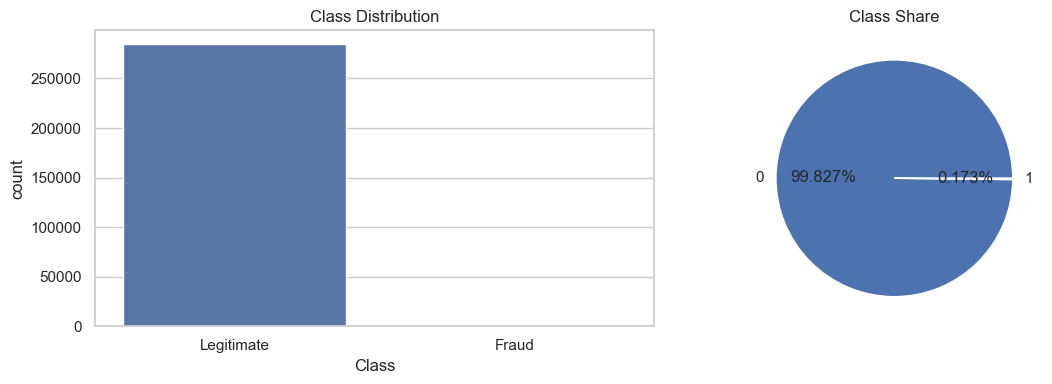

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="Class", ax=axes[0])
axes[0].set_title("Class Distribution")
axes[0].set_xticklabels(["Legitimate", "Fraud"])

target_counts.plot(kind="pie", autopct="%1.3f%%", ax=axes[1])
axes[1].set_ylabel("")
axes[1].set_title("Class Share")

plt.tight_layout()
plt.show()

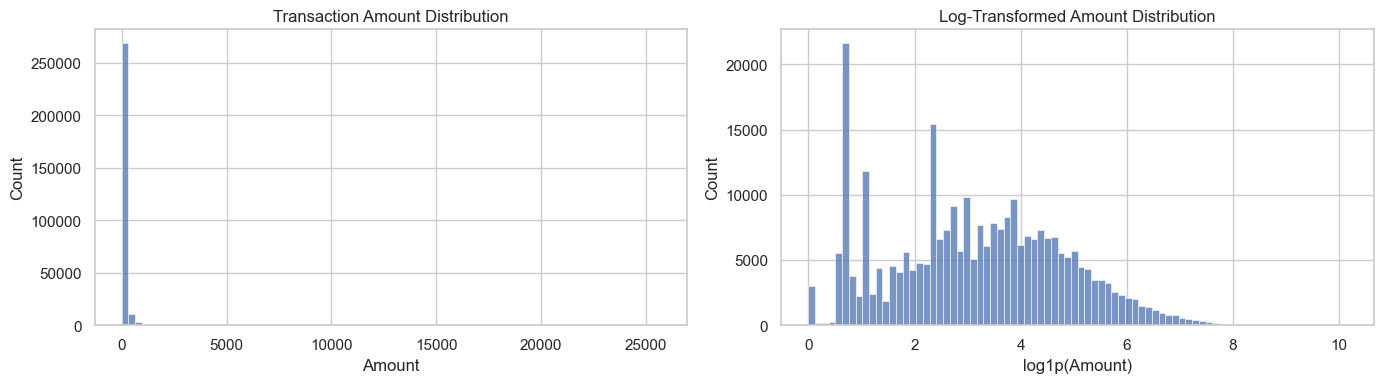

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["Amount"], bins=80, ax=axes[0])
axes[0].set_title("Transaction Amount Distribution")

sns.histplot(np.log1p(df["Amount"]), bins=80, ax=axes[1])
axes[1].set_title("Log-Transformed Amount Distribution")
axes[1].set_xlabel("log1p(Amount)")

plt.tight_layout()
plt.show()

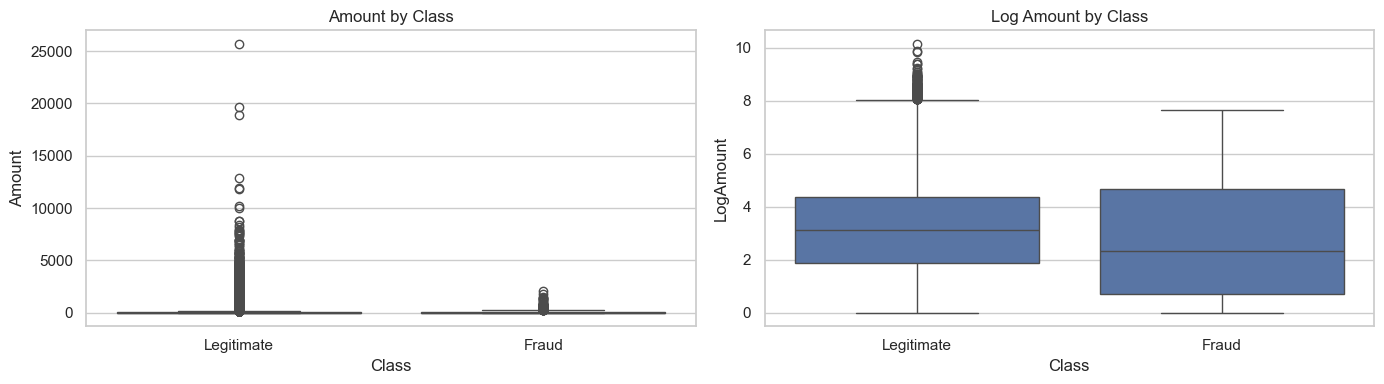

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0])
axes[0].set_title("Amount by Class")
axes[0].set_xticklabels(["Legitimate", "Fraud"])

sns.boxplot(data=df.assign(LogAmount=np.log1p(df["Amount"])), x="Class", y="LogAmount", ax=axes[1])
axes[1].set_title("Log Amount by Class")
axes[1].set_xticklabels(["Legitimate", "Fraud"])

plt.tight_layout()
plt.show()

,correlation_with_fraud
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


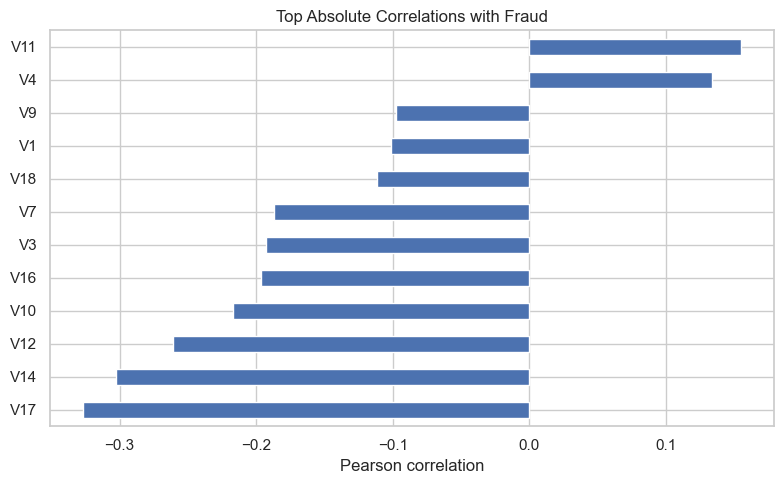

In [9]:
numeric_corr = df.corr(numeric_only=True)["Class"].drop("Class").sort_values(key=np.abs, ascending=False)
display(numeric_corr.head(12).to_frame("correlation_with_fraud"))

plt.figure(figsize=(8, 5))
numeric_corr.head(12).sort_values().plot(kind="barh")
plt.title("Top Absolute Correlations with Fraud")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

## 5. Leakage-Safe Splitting and Preprocessing

The test set is held out until final evaluation. The validation set is used for model selection and threshold tuning.

Preprocessing choices:

- `Amount` is transformed with `log1p` because raw transaction amounts are heavily skewed.
- `Time` is converted into cyclical hour-of-day features.
- Features are scaled inside a `Pipeline`, fit only on training data.
- SMOTE, when used, is inside an `imblearn` pipeline so synthetic samples are created only during training/CV folds.

In [10]:
def add_domain_features(frame):
    # Create simple, leakage-safe features from Time and Amount.
    out = frame.copy()
    out["Amount_log1p"] = np.log1p(out["Amount"])
    out["Hour"] = ((out["Time"] // 3600) % 24).astype(float)
    out["Hour_sin"] = np.sin(2 * np.pi * out["Hour"] / 24)
    out["Hour_cos"] = np.cos(2 * np.pi * out["Hour"] / 24)
    return out.drop(columns=["Amount", "Time", "Hour"])


X = df.drop(columns=["Class"])
y = df["Class"].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

validation_fraction_of_remaining = 0.15 / 0.85
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=validation_fraction_of_remaining,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

print(f"Train:      {X_train.shape}, fraud rate={y_train.mean():.4%}")
print(f"Validation: {X_valid.shape}, fraud rate={y_valid.mean():.4%}")
print(f"Test:       {X_test.shape}, fraud rate={y_test.mean():.4%}")

Train:      (199364, 30), fraud rate=0.1725%
Validation: (42721, 30), fraud rate=0.1732%
Test:       (42722, 30), fraud rate=0.1732%


In [11]:
X_train_fe = add_domain_features(X_train)
feature_names = X_train_fe.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), feature_names),
    ],
    remainder="drop",
)

print(f"Number of model features after engineering: {len(feature_names)}")
print(feature_names[:10], "...")

Number of model features after engineering: 31
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10'] ...


## 6. Utility Functions

In [12]:
def predict_scores(model, X_data):
    # Return positive-class scores for classifiers with either predict_proba or decision_function.
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    return model.predict(X_data)


def evaluate_scores(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def expected_cost(y_true, y_score, threshold, false_positive_cost=1, false_negative_cost=100):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fp * false_positive_cost + fn * false_negative_cost
    return total_cost, total_cost / len(y_true), fp, fn


def find_best_threshold_by_cost(
    y_true,
    y_score,
    false_positive_cost=1,
    false_negative_cost=100,
    thresholds=None,
):
    if thresholds is None:
        thresholds = np.linspace(0.001, 0.999, 999)
    rows = []
    for threshold in thresholds:
        total_cost, cost_per_txn, fp, fn = expected_cost(
            y_true,
            y_score,
            threshold,
            false_positive_cost=false_positive_cost,
            false_negative_cost=false_negative_cost,
        )
        rows.append(
            {
                "threshold": threshold,
                "total_cost": total_cost,
                "cost_per_transaction": cost_per_txn,
                "fp": fp,
                "fn": fn,
            }
        )
    cost_df = pd.DataFrame(rows)
    best_row = cost_df.loc[cost_df["total_cost"].idxmin()]
    return float(best_row["threshold"]), cost_df


def plot_confusion(y_true, y_score, threshold, title):
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred legit", "Pred fraud"],
        yticklabels=["Actual legit", "Actual fraud"],
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 7. Model Development

Models are chosen to satisfy the rubric:

- **Dummy classifier:** trivial majority-class baseline.
- **Logistic regression:** interpretable classical baseline with class weights.
- **Logistic regression + SMOTE:** imbalance-aware version if `imblearn` is available.
- **Random forest:** nonlinear ensemble model.
- **XGBoost or histogram gradient boosting:** higher-capacity boosted model.
- **MLP:** optional neural network baseline; useful to compare, but not expected to dominate on this structured dataset.

In [13]:
models = {
    "Dummy majority": Pipeline(
        steps=[
            ("features", preprocessor),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]
    ),
    "Logistic regression balanced": Pipeline(
        steps=[
            ("features", preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "Random forest balanced": Pipeline(
        steps=[
            ("features", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=150,
                    max_depth=None,
                    min_samples_leaf=2,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "MLP": Pipeline(
        steps=[
            ("features", preprocessor),
            (
                "model",
                MLPClassifier(
                    hidden_layer_sizes=(32, 16),
                    alpha=1e-4,
                    max_iter=30,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

if HAS_IMBLEARN:
    models["Logistic regression + SMOTE"] = ImbPipeline(
        steps=[
            ("features", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.10)),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

if HAS_XGBOOST:
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    models["XGBoost"] = Pipeline(
        steps=[
            ("features", preprocessor),
            (
                "model",
                XGBClassifier(
                    n_estimators=250,
                    max_depth=4,
                    learning_rate=0.05,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    eval_metric="logloss",
                    scale_pos_weight=scale_pos_weight,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )
else:
    models["HistGradientBoosting fallback"] = Pipeline(
        steps=[
            ("features", preprocessor),
            (
                "model",
                HistGradientBoostingClassifier(
                    max_iter=250,
                    learning_rate=0.05,
                    max_leaf_nodes=31,
                    l2_regularization=0.01,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

print("Models to train:")
for name in models:
    print("-", name)

Models to train:
- Dummy majority
- Logistic regression balanced
- Random forest balanced
- MLP
- Logistic regression + SMOTE
- XGBoost


In [14]:
fitted_models = {}
validation_rows = []

for name, model in models.items():
    print(f"Training: {name}")
    fitted = clone(model)
    fitted.fit(add_domain_features(X_train), y_train)
    fitted_models[name] = fitted

    valid_scores = predict_scores(fitted, add_domain_features(X_valid))
    row = evaluate_scores(y_valid, valid_scores, threshold=0.5)
    row["model"] = name
    validation_rows.append(row)

validation_results = (
    pd.DataFrame(validation_rows)
    .set_index("model")
    .sort_values(["pr_auc", "f1"], ascending=False)
)
display(validation_results)

Training: Dummy majority
Training: Logistic regression balanced
Training: Random forest balanced
Training: MLP
Training: Logistic regression + SMOTE
Training: XGBoost


,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
model,,,,,,,,,,
XGBoost,0.5,0.541667,0.878378,0.670103,0.987399,0.853172,42592,55,9,65
Random forest balanced,0.5,0.907692,0.797297,0.848921,0.964327,0.848841,42641,6,15,59
MLP,0.5,0.870968,0.729730,0.794118,0.967626,0.845019,42639,8,20,54
Logistic regression + SMOTE,0.5,0.411392,0.878378,0.560345,0.978140,0.769913,42554,93,9,65
Logistic regression balanced,0.5,0.062214,0.918919,0.116538,0.983603,0.756708,41622,1025,6,68
Dummy majority,0.5,0.000000,0.000000,0.000000,0.500000,0.001732,42647,0,74,0


## 8. Hyperparameter Tuning

To keep runtime realistic, the grid is intentionally small and focuses on the strongest classical baseline: logistic regression with class balancing. If SMOTE is available, the tuning pipeline also includes SMOTE.

In [15]:
if HAS_IMBLEARN:
    tuning_pipeline = ImbPipeline(
        steps=[
            ("features", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)),
        ]
    )
    param_grid = {
        "smote__sampling_strategy": [0.05, 0.10, 0.20],
        "model__C": [0.1, 1.0, 10.0],
    }
else:
    tuning_pipeline = Pipeline(
        steps=[
            ("features", preprocessor),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
        ]
    )
    param_grid = {
        "model__C": [0.1, 1.0, 10.0],
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid.fit(add_domain_features(X_train), y_train)
print("Best parameters:", grid.best_params_)
print(f"Best CV PR-AUC: {grid.best_score_:.4f}")

fitted_models["Tuned logistic/SMOTE"] = grid.best_estimator_
tuned_valid_scores = predict_scores(grid.best_estimator_, add_domain_features(X_valid))
display(pd.DataFrame([evaluate_scores(y_valid, tuned_valid_scores, threshold=0.5)], index=["Tuned logistic/SMOTE"]))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters: {'model__C': 10.0, 'smote__sampling_strategy': 0.05}
Best CV PR-AUC: 0.7736


,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
Tuned logistic/SMOTE,0.5,0.603774,0.864865,0.711111,0.978377,0.770596,42605,42,10,64


## 9. Validation Model Comparison

In [16]:
all_validation_rows = []
for name, fitted in fitted_models.items():
    scores = predict_scores(fitted, add_domain_features(X_valid))
    row = evaluate_scores(y_valid, scores, threshold=0.5)
    row["model"] = name
    all_validation_rows.append(row)

validation_results = (
    pd.DataFrame(all_validation_rows)
    .set_index("model")
    .sort_values(["pr_auc", "f1"], ascending=False)
)
display(validation_results)

selected_model_name = validation_results.index[0]
selected_model = fitted_models[selected_model_name]
print(f"Selected model by validation PR-AUC then F1: {selected_model_name}")

,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
model,,,,,,,,,,
XGBoost,0.5,0.541667,0.878378,0.670103,0.987399,0.853172,42592,55,9,65
Random forest balanced,0.5,0.907692,0.797297,0.848921,0.964327,0.848841,42641,6,15,59
MLP,0.5,0.870968,0.729730,0.794118,0.967626,0.845019,42639,8,20,54
Tuned logistic/SMOTE,0.5,0.603774,0.864865,0.711111,0.978377,0.770596,42605,42,10,64
Logistic regression + SMOTE,0.5,0.411392,0.878378,0.560345,0.978140,0.769913,42554,93,9,65
Logistic regression balanced,0.5,0.062214,0.918919,0.116538,0.983603,0.756708,41622,1025,6,68
Dummy majority,0.5,0.000000,0.000000,0.000000,0.500000,0.001732,42647,0,74,0


Selected model by validation PR-AUC then F1: XGBoost


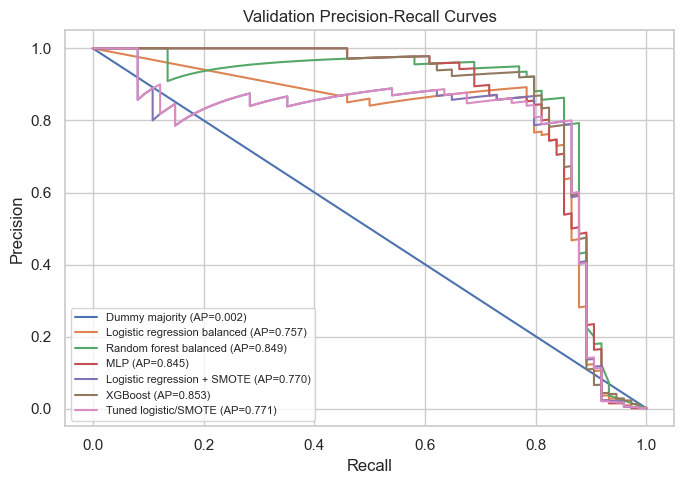

In [17]:
plt.figure(figsize=(7, 5))
for name, fitted in fitted_models.items():
    scores = predict_scores(fitted, add_domain_features(X_valid))
    precision, recall, _ = precision_recall_curve(y_valid, scores)
    plt.plot(recall, precision, label=f"{name} (AP={average_precision_score(y_valid, scores):.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curves")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

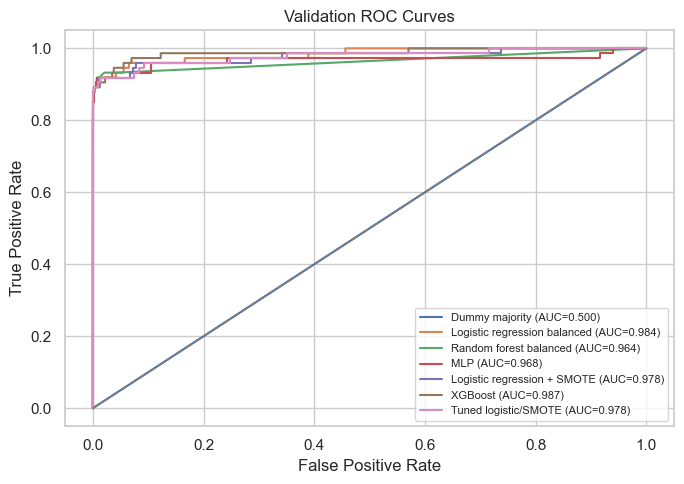

In [18]:
plt.figure(figsize=(7, 5))
for name, fitted in fitted_models.items():
    scores = predict_scores(fitted, add_domain_features(X_valid))
    fpr, tpr, _ = roc_curve(y_valid, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_valid, scores):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## 10. Cost-Sensitive Evaluation and Threshold Tuning

Fraud detection is a cost-sensitive decision problem. The following values are illustrative and should be replaced with real business estimates if available:

- False positive cost = 1 unit: cost of reviewing or blocking a legitimate transaction.
- False negative cost = 100 units: cost of missing a fraudulent transaction.

The model is selected using validation metrics, then its decision threshold is tuned on the validation set to minimize expected cost. The test set is used only once after that threshold is chosen.

In [19]:
FALSE_POSITIVE_COST = 1
FALSE_NEGATIVE_COST = 100

cost_rows = []
cost_curves = {}

for name, fitted in fitted_models.items():
    scores = predict_scores(fitted, add_domain_features(X_valid))
    best_threshold, cost_df = find_best_threshold_by_cost(
        y_valid,
        scores,
        false_positive_cost=FALSE_POSITIVE_COST,
        false_negative_cost=FALSE_NEGATIVE_COST,
    )
    cost_curves[name] = cost_df
    default_cost, default_cost_per_txn, default_fp, default_fn = expected_cost(
        y_valid,
        scores,
        threshold=0.5,
        false_positive_cost=FALSE_POSITIVE_COST,
        false_negative_cost=FALSE_NEGATIVE_COST,
    )
    best_cost, best_cost_per_txn, best_fp, best_fn = expected_cost(
        y_valid,
        scores,
        threshold=best_threshold,
        false_positive_cost=FALSE_POSITIVE_COST,
        false_negative_cost=FALSE_NEGATIVE_COST,
    )
    cost_rows.append(
        {
            "model": name,
            "default_threshold": 0.5,
            "default_total_cost": default_cost,
            "default_fp": default_fp,
            "default_fn": default_fn,
            "best_threshold": best_threshold,
            "best_total_cost": best_cost,
            "best_cost_per_transaction": best_cost_per_txn,
            "best_fp": best_fp,
            "best_fn": best_fn,
        }
    )

cost_results = pd.DataFrame(cost_rows).set_index("model").sort_values("best_total_cost")
display(cost_results)

cost_selected_model_name = cost_results.index[0]
cost_selected_threshold = float(cost_results.loc[cost_selected_model_name, "best_threshold"])
cost_selected_model = fitted_models[cost_selected_model_name]

print(f"Cost-selected model: {cost_selected_model_name}")
print(f"Cost-selected threshold: {cost_selected_threshold:.3f}")

,default_threshold,default_total_cost,default_fp,default_fn,best_threshold,best_total_cost,best_cost_per_transaction,best_fp,best_fn
model,,,,,,,,,
MLP,0.5,2008,8,20,0.028,869,0.020341,69,8
XGBoost,0.5,955,55,9,0.431,873,0.020435,73,8
Logistic regression + SMOTE,0.5,993,93,9,0.482,895,0.020950,95,8
Tuned logistic/SMOTE,0.5,1042,42,10,0.285,897,0.020997,97,8
Random forest balanced,0.5,1506,6,15,0.027,902,0.021114,102,8
Logistic regression balanced,0.5,1625,1025,6,0.911,966,0.022612,166,8
Dummy majority,0.5,7400,0,74,0.001,7400,0.173217,0,74


Cost-selected model: MLP
Cost-selected threshold: 0.028


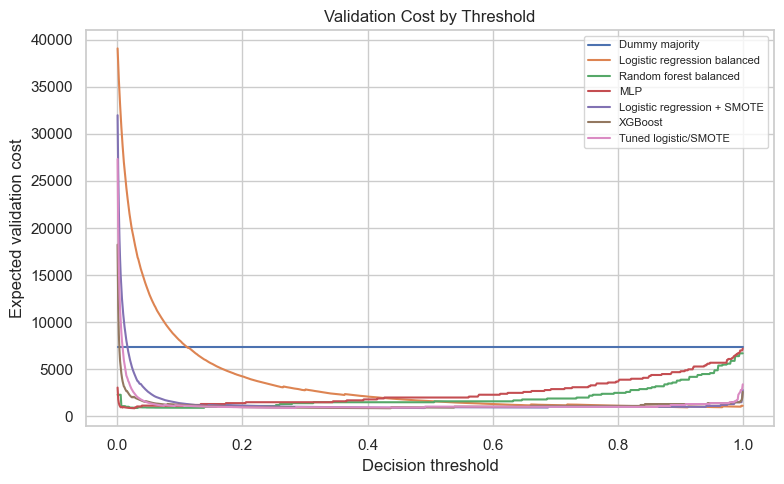

In [20]:
plt.figure(figsize=(8, 5))
for name, cost_df in cost_curves.items():
    plt.plot(cost_df["threshold"], cost_df["total_cost"], label=name)

plt.xlabel("Decision threshold")
plt.ylabel("Expected validation cost")
plt.title("Validation Cost by Threshold")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## 11. Final Test Evaluation

In [21]:
test_scores = predict_scores(cost_selected_model, add_domain_features(X_test))

test_default = evaluate_scores(y_test, test_scores, threshold=0.5)
test_cost_sensitive = evaluate_scores(y_test, test_scores, threshold=cost_selected_threshold)

test_cost_default = expected_cost(
    y_test,
    test_scores,
    threshold=0.5,
    false_positive_cost=FALSE_POSITIVE_COST,
    false_negative_cost=FALSE_NEGATIVE_COST,
)
test_cost_tuned = expected_cost(
    y_test,
    test_scores,
    threshold=cost_selected_threshold,
    false_positive_cost=FALSE_POSITIVE_COST,
    false_negative_cost=FALSE_NEGATIVE_COST,
)

test_summary = pd.DataFrame(
    [
        {**test_default, "setting": "Default threshold", "total_cost": test_cost_default[0], "cost_per_transaction": test_cost_default[1]},
        {**test_cost_sensitive, "setting": "Cost-sensitive threshold", "total_cost": test_cost_tuned[0], "cost_per_transaction": test_cost_tuned[1]},
    ]
).set_index("setting")

print(f"Final model: {cost_selected_model_name}")
display(test_summary)

Final model: MLP


,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,total_cost,cost_per_transaction
setting,,,,,,,,,,,,
Default threshold,0.500,0.896552,0.702703,0.787879,0.964676,0.811883,42642,6,22,52,2206,0.051636
Cost-sensitive threshold,0.028,0.434483,0.851351,0.575342,0.964676,0.811883,42566,82,11,63,1182,0.027667


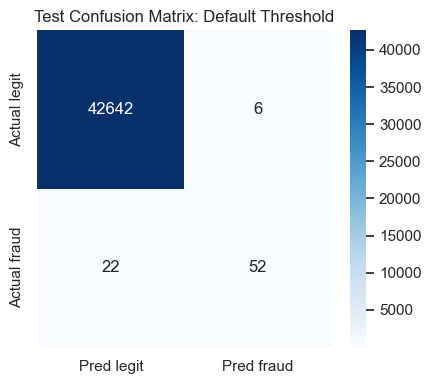

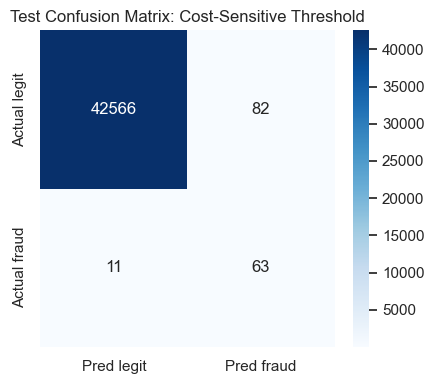

Classification report at cost-sensitive threshold:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42648
       Fraud       0.43      0.85      0.58        74

    accuracy                           1.00     42722
   macro avg       0.72      0.92      0.79     42722
weighted avg       1.00      1.00      1.00     42722



In [22]:
plot_confusion(y_test, test_scores, threshold=0.5, title="Test Confusion Matrix: Default Threshold")
plot_confusion(y_test, test_scores, threshold=cost_selected_threshold, title="Test Confusion Matrix: Cost-Sensitive Threshold")

print("Classification report at cost-sensitive threshold:")
print(classification_report(y_test, (test_scores >= cost_selected_threshold).astype(int), target_names=["Legitimate", "Fraud"], zero_division=0))

## 12. SHAP Interpretability: Baseline vs Advanced Model

This section compares explanations from a baseline logistic model and the selected advanced/cost-sensitive model. The goal is to show whether the more complex model relies on different signals, stronger nonlinear patterns, or similar features with different magnitudes.

For runtime control, SHAP is computed on a sample of the training/test data. If `shap` is not installed, run:

```bash
pip install shap
```

In [23]:
baseline_name = "Logistic regression balanced"
baseline_model = fitted_models.get(baseline_name)

rng = np.random.default_rng(RANDOM_STATE)
background_size = min(500, len(X_train))
explain_size = min(800, len(X_test))

background_idx = rng.choice(len(X_train), size=background_size, replace=False)
explain_idx = rng.choice(len(X_test), size=explain_size, replace=False)

X_background_raw = add_domain_features(X_train).iloc[background_idx]
X_explain_raw = add_domain_features(X_test).iloc[explain_idx]
y_explain = y_test.iloc[explain_idx]

print(f"SHAP background size: {len(X_background_raw)}")
print(f"SHAP explanation sample size: {len(X_explain_raw)}")
print(f"Fraud cases in explanation sample: {int(y_explain.sum())}")

SHAP background size: 500
SHAP explanation sample size: 800
Fraud cases in explanation sample: 0


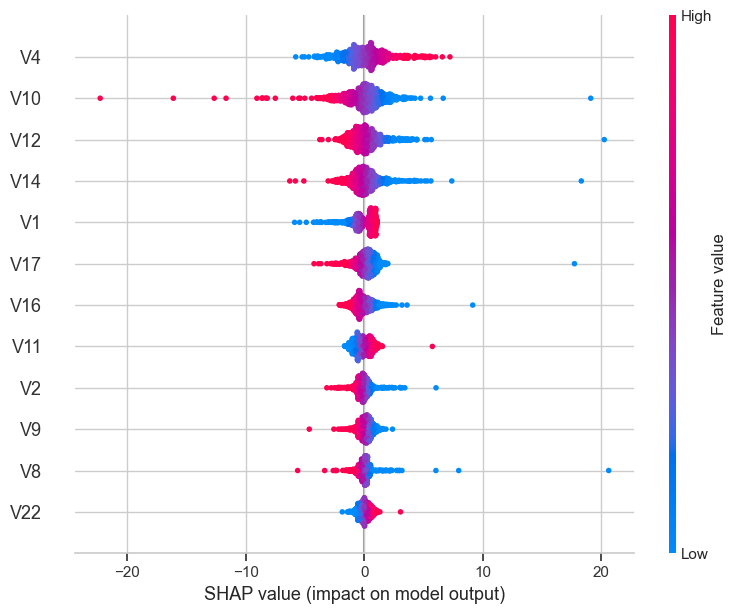

In [24]:
if HAS_SHAP and baseline_model is not None:
    baseline_features = baseline_model.named_steps["features"].transform(X_explain_raw)
    baseline_background = baseline_model.named_steps["features"].transform(X_background_raw)
    baseline_estimator = baseline_model.named_steps["model"]

    baseline_explainer = shap.LinearExplainer(baseline_estimator, baseline_background)
    baseline_shap_values = baseline_explainer(baseline_features)

    shap.summary_plot(
        baseline_shap_values,
        features=baseline_features,
        feature_names=feature_names,
        max_display=12,
        show=True,
    )
else:
    print("Skipping baseline SHAP plot because shap is unavailable or baseline model is missing.")

PermutationExplainer explainer: 801it [01:52,  7.14it/s]                         


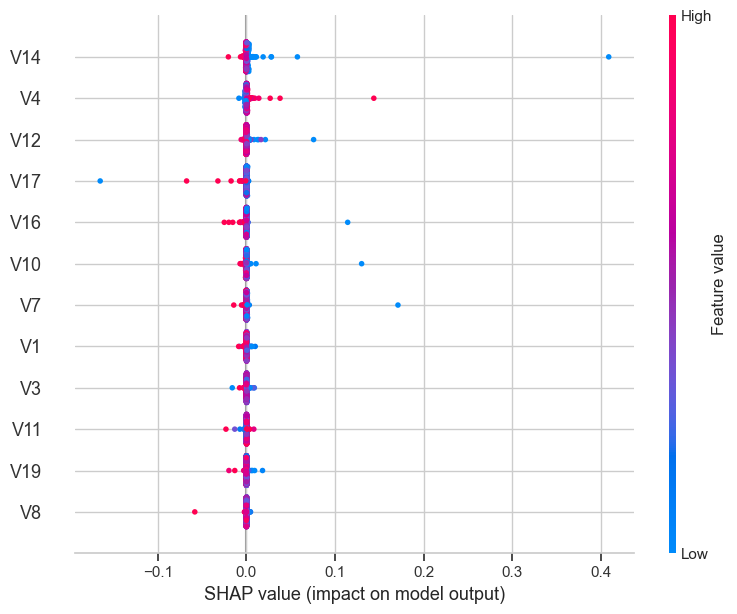

In [25]:
if HAS_SHAP:
    selected_features = cost_selected_model.named_steps["features"].transform(X_explain_raw)
    selected_background = cost_selected_model.named_steps["features"].transform(X_background_raw)
    selected_estimator = cost_selected_model.named_steps["model"]

    if selected_estimator.__class__.__name__ in {"RandomForestClassifier", "XGBClassifier", "HistGradientBoostingClassifier"}:
        advanced_explainer = shap.Explainer(selected_estimator, selected_background, feature_names=feature_names)
        advanced_shap_values = advanced_explainer(selected_features)
        shap.summary_plot(
            advanced_shap_values,
            features=selected_features,
            feature_names=feature_names,
            max_display=12,
            show=True,
        )
    else:
        predict_fn = lambda data: cost_selected_model.named_steps["model"].predict_proba(data)[:, 1]
        advanced_explainer = shap.Explainer(predict_fn, selected_background, feature_names=feature_names)
        advanced_shap_values = advanced_explainer(selected_features)
        shap.summary_plot(
            advanced_shap_values,
            features=selected_features,
            feature_names=feature_names,
            max_display=12,
            show=True,
        )
else:
    print("Skipping advanced SHAP plot because shap is unavailable.")

Permutation importance fallback for the selected model:


,feature,importance
13,V14,0.305371
3,V4,0.072751
11,V12,0.055801
16,V17,0.043942
15,V16,0.039267
9,V10,0.037219
6,V7,0.031400
2,V3,0.030280
10,V11,0.028611
29,Hour_sin,0.014508


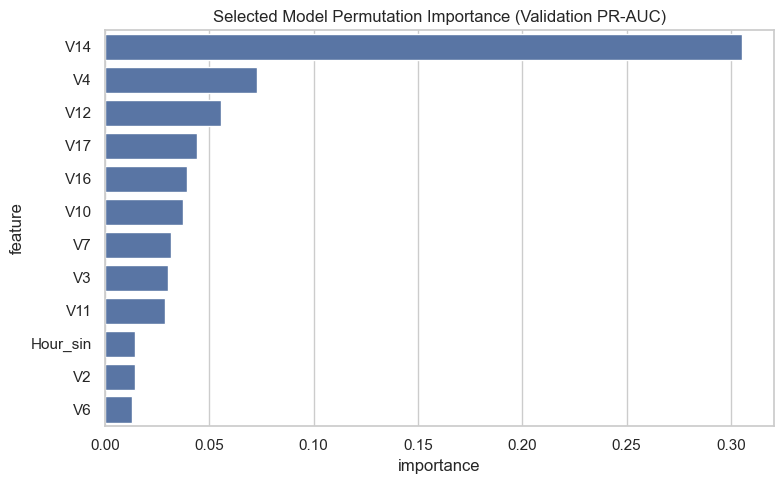

In [26]:
if baseline_model is not None:
    print("Permutation importance fallback for the selected model:")
    perm = permutation_importance(
        cost_selected_model,
        add_domain_features(X_valid),
        y_valid,
        scoring="average_precision",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    perm_df = (
        pd.DataFrame({"feature": feature_names, "importance": perm.importances_mean})
        .sort_values("importance", ascending=False)
        .head(12)
    )
    display(perm_df)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=perm_df, x="importance", y="feature")
    plt.title("Selected Model Permutation Importance (Validation PR-AUC)")
    plt.tight_layout()
    plt.show()

### SHAP Improvement Interpretation

Use the SHAP plots above to compare:

1. Whether the advanced model highlights the same top variables as logistic regression.
2. Whether feature effects are more asymmetric or nonlinear in the advanced model.
3. Whether model complexity improves fraud recall or PR-AUC enough to justify lower interpretability.

In the final report, summarize the comparison in plain language: for example, "The advanced model improved PR-AUC and reduced expected cost, while SHAP showed that it relied more strongly on features V14, V10, and V4 than the logistic baseline."

## 13. Failure-Mode Analysis

In [27]:
test_pred = (test_scores >= cost_selected_threshold).astype(int)
test_analysis = X_test.copy()
test_analysis["actual"] = y_test.values
test_analysis["score"] = test_scores
test_analysis["predicted"] = test_pred
test_analysis["error_type"] = np.select(
    [
        (test_analysis["actual"] == 1) & (test_analysis["predicted"] == 0),
        (test_analysis["actual"] == 0) & (test_analysis["predicted"] == 1),
        (test_analysis["actual"] == 1) & (test_analysis["predicted"] == 1),
        (test_analysis["actual"] == 0) & (test_analysis["predicted"] == 0),
    ],
    ["False negative", "False positive", "True positive", "True negative"],
    default=""
)

display(test_analysis["error_type"].value_counts().to_frame("count"))

false_negatives = test_analysis[test_analysis["error_type"] == "False negative"].sort_values("score", ascending=False)
false_positives = test_analysis[test_analysis["error_type"] == "False positive"].sort_values("score", ascending=False)

print("False negatives: fraud cases missed by the model")
display(false_negatives.head(10))

print("False positives: legitimate transactions flagged for review")
display(false_positives.head(10))

,count
error_type,
True negative,42566
False positive,82
True positive,63
False negative,11


False negatives: fraud cases missed by the model


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,actual,score,predicted,error_type
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,-0.414575,-0.503141,0.676502,-1.692029,2.000635,0.666780,0.599717,1.725321,0.283345,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1,0.002596,0,False negative
245347,152710.0,0.051075,1.310427,0.733222,2.620282,1.402358,0.528489,1.086014,-0.146423,-1.724333,1.280167,0.470865,0.435542,0.594974,-0.142099,-2.024735,0.828291,-1.274787,0.134277,-1.489434,-0.125877,0.229936,0.766927,-0.189624,0.766853,-0.141401,-0.077278,-0.297595,-0.221816,2.47,1,0.002480,0,False negative
10497,17220.0,1.189784,0.942289,0.082334,3.024050,0.412406,-0.214415,0.053558,-0.110353,0.883798,-0.554224,0.154921,-2.776757,1.641207,-0.456077,-1.240414,0.857323,1.707024,0.526349,-0.865105,-0.143435,-0.502636,-1.047398,-0.056752,-0.340688,0.541235,-0.098300,-0.003041,0.049819,3.79,1,0.001109,0,False negative
157585,110087.0,1.934946,0.650678,-0.286957,3.987828,0.316052,-0.099449,-0.021483,-0.172327,0.508730,1.072955,-0.427567,-2.777649,1.637140,1.571080,-1.445367,0.908650,-0.122016,-0.104110,-1.684022,-0.344452,-0.173602,-0.190974,0.219976,-0.216597,-0.136692,-0.129954,-0.050077,-0.051082,1.00,1,0.000510,0,False negative
119714,75556.0,-0.734303,0.435519,-0.530866,-0.471120,0.643214,0.713832,-1.234572,-2.551412,-2.057724,0.166831,0.567552,-0.858060,-0.448068,-0.264936,0.888863,0.838121,1.425060,-0.169664,2.502027,0.864536,-1.004877,1.150354,-0.152555,-1.386745,0.004716,0.219146,-0.058257,0.158048,29.95,1,0.000466,0,False negative
157918,110617.0,-1.101035,-1.674928,-0.573388,5.617556,0.765556,0.440607,1.934740,-1.019788,-0.193244,1.783739,0.606911,-2.854275,2.379473,1.268147,-0.283619,-0.482192,0.811005,-0.357911,0.752761,-0.038314,-0.412526,-0.208823,0.344833,1.091435,-0.686513,0.075809,0.033865,-0.832855,635.10,1,0.000305,0,False negative
96341,65728.0,1.227614,-0.668974,-0.271785,-0.589440,-0.604795,-0.350285,-0.486365,-0.010809,-0.794944,0.264545,0.881268,-0.324704,-0.263264,-1.112735,-0.540850,1.533411,0.831443,-0.473347,1.190121,0.273799,-0.026055,-0.295255,-0.180459,-0.436539,0.494649,-0.283738,-0.001128,0.035075,98.01,1,0.000248,0,False negative
68067,52814.0,-1.101847,-1.632441,0.901067,0.847753,-1.249091,0.654937,1.448868,0.023308,-0.136742,-0.150129,1.172355,-0.795988,-2.136951,0.578869,1.412115,0.013467,-0.119204,0.826814,0.476860,1.230278,0.610654,0.835795,1.179955,-0.029091,-0.300896,0.699175,-0.336072,-0.177587,519.90,1,0.000218,0,False negative
219025,141565.0,0.114965,0.766762,-0.494132,0.116772,0.868169,-0.477982,0.438496,0.063073,-0.186207,-0.159325,1.200304,0.281744,-0.623844,-0.658246,-0.155888,0.056227,0.653662,0.334655,1.028927,0.062199,-0.284413,-0.706865,0.131405,0.600742,-0.604264,0.262938,0.099145,0.010810,4.49,1,0.000080,0,False negative
72757,54846.0,-2.986466,-0.000891,0.605887,0.338338,0.685448,-1.581954,0.504206,-0.233403,0.636768,1.010291,0.004518,0.044397,0.420853,-0.931614,1.147974,0.483063,-0.152471,-0.285666,0.072550,-0.764274,-0.875146,-0.509849,1.313918,0.355065,0.448552,0.193490,1.214588,-0.013923,1.79,1,0.000062,0,False negative


False positives: legitimate transactions flagged for review


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,actual,score,predicted,error_type
153457,99129.0,-3.141115,2.014154,-0.610409,5.946659,-1.868534,0.756737,-3.313842,0.227978,-0.937894,-0.976492,3.050599,-6.930605,0.118405,-1.931536,-0.569347,-2.976084,-5.396702,-0.780563,1.906558,-0.563324,1.408511,0.800389,0.514926,-0.049373,-0.510364,0.442583,-0.165737,0.682784,45.51,0,0.821298,1,False positive
153398,98904.0,-2.690251,1.465266,-0.691844,4.322855,-1.086880,0.063585,-2.966872,-0.059646,-0.090827,-1.291980,2.969599,-6.835634,-0.226037,-2.484695,-2.207474,-1.883016,-6.675449,-1.273625,-1.161245,-0.632750,1.211390,0.259112,0.610188,-0.119366,0.028077,-0.044074,0.005614,0.557189,0.00,0,0.663243,1,False positive
191296,129198.0,1.409526,0.804290,-1.132910,4.389033,-0.713480,0.381632,-1.949727,0.481483,-1.029737,-0.309069,-0.678748,-2.285944,0.603204,-2.538397,-0.619315,-0.733171,-4.691921,-1.231856,-1.143013,0.005499,0.472801,0.690423,0.057314,-0.669954,-0.012138,0.141410,0.355679,0.113299,0.00,0,0.661656,1,False positive
17592,28818.0,-2.181281,3.422398,-6.628457,4.096195,-2.558534,-2.902141,-4.627348,1.783160,-2.689058,-6.959551,4.146474,-8.203205,-1.415738,-10.006650,1.065094,-5.502404,-8.902106,-2.752053,1.024737,0.792160,0.890441,-0.286284,0.049511,-0.063265,-0.158701,-0.297131,1.348460,0.330177,89.99,0,0.635572,1,False positive
10783,18359.0,-4.071799,4.929765,-9.523349,5.791918,-4.772561,-3.307247,-8.513680,3.073999,-3.297625,-10.957551,9.540746,-14.745849,0.078563,-13.127971,-0.489528,-9.860339,-16.511143,-5.114520,2.001710,1.356943,1.503540,-0.331471,-0.023827,-0.017298,-0.003155,-0.302673,2.074226,0.662986,89.99,0,0.613342,1,False positive
18150,29234.0,-4.171674,4.308450,-8.239315,4.168997,-3.855552,-3.023051,-5.521171,3.046835,-2.612760,-6.746047,3.789346,-7.683643,-1.189551,-9.257521,1.036380,-5.139197,-8.430967,-2.696048,0.901397,0.818596,0.902861,-0.448209,-0.061721,-0.052563,0.004487,-0.293409,1.281466,0.307834,89.99,0,0.535282,1,False positive
19145,30047.0,-5.345558,5.116875,-9.270055,4.151766,-4.839258,-3.001705,-5.982505,3.892781,-2.587959,-6.624982,3.546377,-7.367772,-1.051471,-8.777934,0.998339,-4.906529,-8.125767,-2.644697,0.834801,0.812660,0.902817,-0.491616,0.217218,-0.065900,0.197834,-0.277323,1.242472,0.281893,89.99,0,0.488554,1,False positive
12229,21377.0,-6.598245,6.287066,-11.602230,5.839793,-6.457723,-3.478503,-9.760867,4.768155,-3.196978,-10.656148,9.061094,-14.057800,0.365764,-12.137460,-0.541332,-9.392541,-15.882021,-5.042858,1.846474,1.355294,1.513373,-0.523758,-0.106542,-0.008267,0.229719,-0.290765,2.004635,0.631212,89.99,0,0.446756,1,False positive
277737,167826.0,-6.629470,2.872588,-4.817947,0.799106,-2.842538,-1.941351,-4.609837,2.130611,-1.582576,-3.419968,1.688688,-2.815563,-1.509545,-1.026449,-0.279815,-2.542799,-5.781199,-1.420272,0.731522,-1.622647,1.903358,0.551154,-0.621414,0.086836,0.233894,-0.256196,-1.861764,0.261256,1.00,0,0.349690,1,False positive
13394,23665.0,-9.925356,7.745653,-14.285390,5.964859,-8.605175,-3.690203,-11.259379,6.878428,-3.070914,-10.301635,8.464554,-13.191108,0.742861,-10.886933,-0.590103,-8.789375,-15.095898,-4.946567,1.639382,1.422021,1.541435,-0.794712,-0.273693,0.007951,0.504524,-0.285121,1.884470,0.597549,89.99,0,0.319081,1,False positive


In [28]:
def compare_error_group(group_name, rows):
    if rows.empty:
        print(f"No {group_name} cases to summarize.")
        return
    summary = rows[["Amount", "Time", "score"]].describe().T
    print(group_name)
    display(summary)


compare_error_group("False negatives", false_negatives)
compare_error_group("False positives", false_positives)

fraud_test = test_analysis[test_analysis["actual"] == 1]
compare_error_group("All actual fraud in test set", fraud_test)

False negatives


,count,mean,std,min,25%,50%,75%,max
Amount,11.0,166.045455,257.051705,1.000000,2.130000,4.490000,308.955000,635.100000
Time,11.0,75104.272727,48759.843747,472.000000,48673.000000,65728.000000,110352.000000,152710.000000
score,11.0,0.000734,0.000942,0.000003,0.000149,0.000305,0.000809,0.002596


False positives


,count,mean,std,min,25%,50%,75%,max
Amount,82.0,76.878049,232.435827,0.000000,1.000000,13.250000,75.77250,1888.430000
Time,82.0,94548.731707,50116.915291,1470.000000,54599.500000,98970.000000,136208.50000,167826.000000
score,82.0,0.151195,0.175230,0.028219,0.037235,0.071899,0.20344,0.821298


All actual fraud in test set


,count,mean,std,min,25%,50%,75%,max
Amount,74.0,98.090000,165.659645,0.000000,1.000000,9.620000,108.772500,802.520000
Time,74.0,75087.391892,45935.487439,472.000000,41140.250000,69811.500000,99402.750000,169347.000000
score,74.0,0.655957,0.373555,0.000003,0.321694,0.859162,0.967502,0.999831


## 14. Ethical and Practical Reflection

Important limitations:

- The dataset is anonymized with PCA-transformed variables, which protects privacy but limits domain interpretation.
- The positive class is extremely rare, so metrics have high uncertainty and should be interpreted carefully.
- A model that maximizes recall may create many false alarms, which can harm customer experience.
- A model that maximizes precision may miss fraud, causing financial loss.
- The illustrative cost matrix may not match a real bank's operational costs.
- Fraud patterns change over time, so a deployed system would require monitoring and retraining.

Responsible deployment would include human review for high-risk cases, threshold monitoring, drift detection, and regular fairness/bias checks across customer segments if such attributes were available and legally appropriate to use.

## 15. Conclusions

This project demonstrates a complete fraud-detection ML workflow:

- The problem is a severely imbalanced binary classification task.
- Accuracy alone is misleading; recall, PR-AUC, F1, and expected cost are more relevant.
- Leakage-safe preprocessing and validation are essential.
- Class weights and SMOTE help address class imbalance.
- Cost-sensitive threshold tuning can reduce business loss compared with the default 0.5 threshold.
- SHAP and permutation importance make the model behavior more transparent.

The final model should be selected based on both statistical performance and practical tradeoffs: catching fraud, controlling false alarms, reducing expected cost, and remaining explainable enough for financial decision-making.